                     Date  Fremont Bridge Total  Fremont Bridge East Sidewalk  \
0  11/01/2019 12:00:00 AM                  12.0                           7.0   
1  11/01/2019 01:00:00 AM                   7.0                           0.0   
2  11/01/2019 02:00:00 AM                   1.0                           0.0   
3  11/01/2019 03:00:00 AM                   6.0                           6.0   
4  11/01/2019 04:00:00 AM                   6.0                           5.0   

   Fremont Bridge West Sidewalk  
0                           5.0  
1                           7.0  
2                           1.0  
3                           0.0  
4                           1.0  

K-Means Clusters:
Cluster
1.0        102848
2.0         34345
0.0         10062
Name: count, dtype: int64


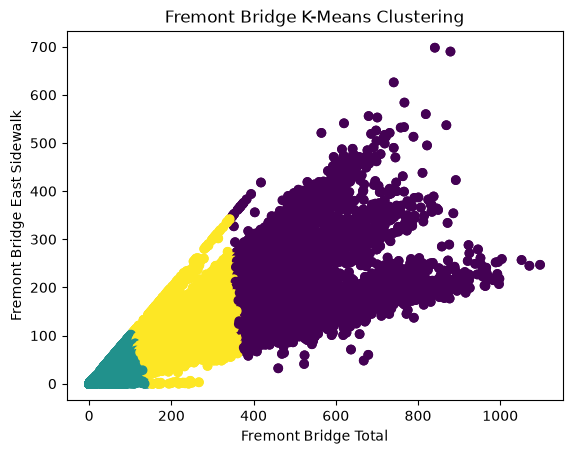

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5777/264160588.py:39: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns



NLP Clusters:
NLP_Cluster
2    75258
1    45135
0    26885
Name: count, dtype: int64

Done! Results saved as FremontBridge_Result.csv


In [1]:
# Install if needed:
# !pip install pandas matplotlib scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

# Load dataset
df = pd.read_csv("FremontBridge.csv")
print(df.head())

# ---------- K-MEANS ----------
# Select numeric columns
num = df.select_dtypes(include="number").dropna()

# Scale data
X = StandardScaler().fit_transform(num)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df.loc[num.index, "Cluster"] = kmeans.fit_predict(X)

print("\nK-Means Clusters:")
print(df[["Cluster"]].value_counts())

# Plot
plt.scatter(num.iloc[:, 0], num.iloc[:, 1],
            c=df.loc[num.index, "Cluster"])
plt.xlabel(num.columns[0])
plt.ylabel(num.columns[1])
plt.title("Fremont Bridge K-Means Clustering")
plt.show()


# ---------- NLP ----------
# Convert all text/object columns into text
text_cols = df.select_dtypes(include="object").columns

if len(text_cols) > 0:
    text = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

    # TF-IDF
    tfidf = TfidfVectorizer(stop_words="english")
    X_text = tfidf.fit_transform(text)

    # NLP K-Means
    nlp = KMeans(n_clusters=3, random_state=42, n_init=10)
    df["NLP_Cluster"] = nlp.fit_predict(X_text)

    print("\nNLP Clusters:")
    print(df["NLP_Cluster"].value_counts())

# Save result
df.to_csv("FremontBridge_Result.csv", index=False)

print("\nDone! Results saved as FremontBridge_Result.csv")